In [3]:
import numpy as np

In [4]:
class LinearRegression:
    def __init__(self,learning_rate=0.01,itr=1000):
        self.Bias=None
        self.weights=None
        self.lr_rate=learning_rate
        self.iter=itr

    def fit(self,x,y):
        m,n=x.shape
        #step 1 - Initialize Param
        self.Bias=0
        self.weights=np.zeros(n)

        # Geadient Descent
        for i in range(self.iter):
            # step 2 -Clac Y predictions
            y_pred=self.Bias+np.dot(x,self.weights)
    
            # Step 3 - Calc Gradient
            db=(1/m) * np.sum(y_pred-y)
            dw=(1/m) * np.dot(x.T,(y_pred-y))
    
            # step 4 - Convergance theorem and pred
            self.Bias -=self.lr_rate* db
            self.weights -=self.lr_rate *dw
        
    def predicted(self,x):
        y_pred=self.Bias+np.dot(x,self.weights)
        return y_pred

In [6]:
x=np.array([[1],[2],[3],[4],[5]])
y=np.array([2,4,6,8,10])

model=LinearRegression()
model.fit(x,y)

y_pred=model.predicted(x)
print(y_pred)

[2.06850809 4.04226297 6.01601785 7.98977273 9.96352761]


# Linear Regression with OLS (Ordinary Least Squares)

## Introduction

**Linear Regression** is a supervised machine learning algorithm used to predict continuous numerical values.

The objective of Linear Regression is to find the **Best Fit Line** that minimizes the prediction error.

One of the most common methods to find the best parameters is called **Ordinary Least Squares (OLS)**.

OLS calculates the values of **Bias (Intercept)** and **Weights (Coefficients)** by minimizing the **Sum of Squared Errors (SSE)**.

---

# Cost Function (Least Squares)

Suppose

- Actual value = $y$
- Predicted value = $\hat{y}$

The error is

$$
Error = y-\hat y
$$

Since positive and negative errors cancel each other, we square every error.

The objective function becomes

$$
J(\theta)=\sum_{i=1}^{m}(y_i-\hat y_i)^2
$$

where

- $m$ = Number of training examples
- $\theta$ = Model parameters

OLS tries to minimize this cost function.

---

# Normal Equation

Instead of using Gradient Descent, OLS directly calculates the optimal parameters using the **Normal Equation**.

The formula is

$$
\boxed{
\theta=(X^TX)^{-1}X^Ty
}
$$

where

- $X$ = Feature Matrix
- $X^T$ = Transpose of X
- $y$ = Target Vector
- $\theta$ = Parameters (Bias + Weights)

---

# Matrix Breakdown

The Normal Equation can be divided into two parts.

### Step 1

$$
A=(X^TX)^{-1}
$$

First calculate

$$
X^TX
$$

Then find its inverse.

---

### Step 2

$$
B=X^Ty
$$

Multiply the transpose of X with y.

---

### Step 3

Finally,

$$
\theta=A\times B
$$

or

$$
\theta=(X^TX)^{-1}X^Ty
$$

---

# Understanding the Parameters

Suppose

$$
\theta=
\begin{bmatrix}
b\\
w_1\\
w_2
\end{bmatrix}
$$

where

- First value = Bias (Intercept)
- Remaining values = Weights (Coefficients)

---

# Prediction Formula

After calculating the parameters,

Prediction is

$$
\hat y=b+w_1x_1+w_2x_2+\cdots+w_nx_n
$$

---

# Advantages of OLS

- Gives the exact mathematical solution.
- No learning rate is required.
- No iterations are needed.
- Fast for small datasets.
- Simple to implement.

---

# Disadvantages of OLS

- Matrix inversion is computationally expensive.
- Slow for very large datasets.
- Cannot be used if $(X^TX)$ is non-invertible.
- Sensitive to multicollinearity.
- Sensitive to outliers.

---

# Summary

The complete workflow of OLS is

1. Prepare the feature matrix.
2. Add a column of ones for the bias term.
3. Compute

$$
X^TX
$$

4. Compute its inverse

$$
(X^TX)^{-1}
$$

5. Compute

$$
X^Ty
$$

6. Multiply both matrices

$$
\theta=(X^TX)^{-1}X^Ty
$$

7. Extract Bias and Weights.
8. Predict using

$$
\hat y=b+Xw
$$

> OLS directly computes the optimal parameters without using Gradient Descent. It is simple, mathematically exact, and works well for small to medium-sized datasets.

In [7]:
import numpy as np

class LinearRegressionOLS:

    def __init__(self):
        self.bias = None
        self.weights = None

    def fit(self, X, y):

        # Number of samples
        m, n = X.shape

        # Add bias column
        X_b = np.c_[np.ones((m, 1)), X]

        # Normal Equation
        theta = np.linalg.inv(X_b.T @ X_b) @ (X_b.T @ y)

        # Store parameters
        self.bias = theta[0]
        self.weights = theta[1:]

    def predict(self, X):

        y_pred = self.bias + np.dot(X, self.weights)

        return y_pred

In [8]:
X = np.array([[1],
              [2],
              [3],
              [4],
              [5]])

y = np.array([2,4,6,8,10])

model = LinearRegressionOLS()

model.fit(X, y)

y_pred = model.predict(X)

print("Predictions:")
print(y_pred)

print("\nBias:")
print(model.bias)

print("\nWeights:")
print(model.weights)

Predictions:
[ 2.  4.  6.  8. 10.]

Bias:
0.0

Weights:
[2.]


# Logistic Regression

## Introduction

**Logistic Regression** is a **Supervised Machine Learning Algorithm** used for **Binary Classification** problems.

Unlike Linear Regression, Logistic Regression predicts the **probability** that a data point belongs to a particular class.

The output of Logistic Regression always lies between

$$
0 \le \hat y \le 1
$$

Common applications include:

- Spam Detection
- Disease Prediction
- Fraud Detection
- Customer Churn Prediction

---

# Why Not Linear Regression?

Linear Regression can produce values less than 0 or greater than 1.

For classification, we need probabilities between **0 and 1**.

To solve this problem, Logistic Regression uses the **Sigmoid Function**.

---

# Linear Equation

First compute

$$
z=\theta_0+\theta_1x_1+\theta_2x_2+\cdots+\theta_nx_n
$$

or in matrix form

$$
z=\theta^TX
$$

where

- $\theta_0$ = Bias
- $\theta_1,\theta_2,\dots$ = Weights

---

# Sigmoid Function

The Sigmoid Function converts any real value into a probability between **0 and 1**.

$$
g(z)=\frac{1}{1+e^{-z}}
$$

Properties

- Output is always between **0 and 1**
- Large positive values become close to **1**
- Large negative values become close to **0**

---

# Prediction Function

The predicted probability is

$$
\hat y=g(z)
$$

or

$$
\hat y=\frac{1}{1+e^{-z}}
$$

---

# Decision Boundary

A threshold is used to convert probability into classes.

Usually

$$
Threshold=0.5
$$

If

$$
\hat y\ge0.5
$$

Predict

$$
1
$$

Otherwise

$$
0
$$

---

# Cost Function

Logistic Regression uses **Binary Cross Entropy (Log Loss)**.

$$
J(\theta)
=
-\frac1m
\sum_{i=1}^{m}
\left[
y^{(i)}
\log(\hat y^{(i)})
+
(1-y^{(i)})
\log(1-\hat y^{(i)})
\right]
$$

where

- $m$ = Number of samples
- $y$ = Actual value
- $\hat y$ = Predicted probability

The objective is to minimize this cost.

---

# Gradient Descent

Bias gradient

$$
db=\frac1m\sum(\hat y-y)
$$

Weight gradient

$$
dw=\frac1mX^T(\hat y-y)
$$

Update equations

Bias

$$
b=b-\alpha db
$$

Weights

$$
w=w-\alpha dw
$$

where

- $\alpha$ = Learning Rate

---

# Algorithm

1. Initialize Bias and Weights.
2. Calculate

$$
z=XW+b
$$

3. Apply Sigmoid Function.
4. Calculate Cost.
5. Compute Gradients.
6. Update Weights.
7. Repeat until convergence.
8. Predict using threshold.

---

# Advantages

- Simple and easy to implement.
- Fast training.
- Outputs probabilities.
- Works well for binary classification.
- Easy to interpret.

---

# Disadvantages

- Works only for linear decision boundaries.
- Sensitive to outliers.
- Requires feature scaling for better convergence.
- Cannot model highly complex relationships.

---

# Summary

The complete workflow of Logistic Regression is

1. Compute Linear Equation

$$
z=XW+b
$$

2. Apply Sigmoid Function

$$
\hat y=\frac1{1+e^{-z}}
$$

3. Compute Binary Cross Entropy Loss.

4. Calculate Gradients.

5. Update Parameters using Gradient Descent.

6. Predict

- Probability ≥ 0.5 → Class 1
- Probability < 0.5 → Class 0

> Logistic Regression is one of the most popular machine learning algorithms for binary classification because it is simple, efficient, interpretable, and produces probability-based predictions.

In [9]:
import numpy as np

class LogisticRegression:

    def __init__(self, learning_rate=0.1, n_iter=1000):
        self.bias = None
        self.weights = None
        self.lr = learning_rate
        self.n_iter = n_iter

    # Sigmoid Function
    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    # Training
    def fit(self, X, y):

        m, n = X.shape

        # Initialize Parameters
        self.bias = 0
        self.weights = np.zeros(n)

        # Gradient Descent
        for _ in range(self.n_iter):

            # Linear Equation
            z = self.bias + np.dot(X, self.weights)

            # Sigmoid
            y_pred = self._sigmoid(z)

            # Gradients
            db = (1 / m) * np.sum(y_pred - y)
            dw = (1 / m) * np.dot(X.T, (y_pred - y))

            # Update Parameters
            self.bias -= self.lr * db
            self.weights -= self.lr * dw

    # Probability
    def get_probabilities(self, X):
        z = self.bias + np.dot(X, self.weights)
        return self._sigmoid(z)

    # Prediction
    def predict(self, X, threshold=0.5):
        probabilities = self.get_probabilities(X)
        y_pred = probabilities >= threshold
        return y_pred.astype(int)

In [10]:


X = np.array([
    [1, 2],
    [2, 3],
    [3, 4],
    [4, 5]
])

y = np.array([0, 0, 1, 1])

model = LogisticRegression(
    learning_rate=0.1,
    n_iter=1000
)

model.fit(X, y)

y_pred = model.predict(X)

print("Predictions:")
print(y_pred)

print("\nProbabilities:")
print(model.get_probabilities(X))

print("\nBias:")
print(model.bias)

print("\nWeights:")
print(model.weights)

Predictions:
[0 0 1 1]

Probabilities:
[0.02871674 0.26532955 0.81521201 0.98178143]

Bias:
-4.85011370257949

Weights:
[ 3.67640108 -1.17371262]


# k-Nearest Neighbors (KNN)

## Introduction

**k-Nearest Neighbors (KNN)** is a **Supervised Machine Learning Algorithm** used for both **Classification** and **Regression** problems.

It is called a **Lazy Learning Algorithm** because it does **not train a model**. Instead, it stores the complete training dataset and performs all computations only when a new data point is given.

---

# How KNN Works

The KNN algorithm follows these steps:

### Step 1: Choose the Value of K

- Select the number of nearest neighbours (**K**).
- K is a **Hyperparameter**.
- Usually an **odd value** (3, 5, 7, 9, ...) is selected for classification to avoid ties.

Example:

If

\[
K = 5
\]

the algorithm will consider the **5 nearest neighbours**.

---

### Step 2: Calculate Distance

For the new data point, calculate the distance from every training sample.

After calculating all distances:

- Sort all distances.
- Select the **K nearest neighbours** having the minimum distance.

---

# Distance Metrics

## 1. Euclidean Distance

Euclidean Distance is the shortest straight-line distance between two points.

Suppose two points are

\[
P_1(x_1,y_1)
\]

and

\[
P_2(x_2,y_2)
\]

### Formula

\[
d=\sqrt{(x_2-x_1)^2+(y_2-y_1)^2}
\]

### Example

If

\[
P_1=(2,3)
\]

and

\[
P_2=(5,7)
\]

then

\[
d=\sqrt{(5-2)^2+(7-3)^2}
\]

\[
=\sqrt{9+16}
\]

\[
=\sqrt{25}=5
\]

---

## 2. Manhattan Distance

Manhattan Distance measures distance by moving horizontally and vertically.

### Formula

\[
d=|x_2-x_1|+|y_2-y_1|
\]

### Example

If

\[
P_1=(2,3)
\]

and

\[
P_2=(5,7)
\]

then

\[
d=|5-2|+|7-3|
\]

\[
=3+4=7
\]

---

# Step 3: Make Prediction

After selecting the **K nearest neighbours**, prediction is made.

## Classification

For classification:

- Count the class labels of the K nearest neighbours.
- The class with the **highest frequency** is selected.

This method is called **Majority Voting**.

### Example

If

\[
K=5
\]

Nearest neighbours are:

| Neighbour | Class |
|-----------|-------|
| 1 | A |
| 2 | A |
| 3 | B |
| 4 | A |
| 5 | B |

Then

A = 3

B = 2

Predicted Class:

\[
A
\]

---

## Regression

For regression:

Take the **average (mean)** of the target values of the K nearest neighbours.

### Formula

\[
\hat{y}=\frac{y_1+y_2+\cdots+y_K}{K}
\]

### Example

Neighbour values:

20, 22, 24, 26, 28

\[
\hat{y}
=
\frac{20+22+24+26+28}{5}
=
24
\]

---

# Choosing the Value of K

### Small K

- More flexible
- Sensitive to noise
- Can cause Overfitting

### Large K

- More stable
- Less affected by noise
- Can cause Underfitting

---

# Why Feature Scaling is Required

KNN is completely based on **distance**.

If one feature has much larger values than another, it dominates the distance calculation.

Therefore, **Feature Scaling** (Standardization or Normalization) should be applied before using KNN.

---

# Advantages

- Simple and easy to understand.
- Easy to implement.
- No training phase.
- Works for Classification and Regression.
- Handles non-linear data well.
- Good for small datasets.

---

# Disadvantages

- Slow on large datasets.
- Prediction becomes expensive.
- Stores the entire training dataset.
- Sensitive to irrelevant features.
- Sensitive to the value of K.
- Requires Feature Scaling.

---

# Summary

The KNN algorithm works as follows:

1. Choose the value of **K**.
2. Calculate the distance between the new data point and all training samples.
3. Select the **K nearest neighbours**.
4. For Classification, use **Majority Voting**.
5. For Regression, calculate the **Average (Mean)** of the neighbours' target values.

KNN is one of the simplest and most powerful supervised machine learning algorithms. It is an excellent choice for beginners because it is easy to understand and forms the foundation for many machine learning concepts.

In [11]:
import numpy as np
import seaborn as sns
import pandas as pd

In [12]:
# KNN Implementation from scratch - for binary classification

class KNNClassifier:
    def __init__(self, k=3):
        self.k = k
    
    def _euclidean_dist(self, x1, x2):
        return np.sqrt(np.sum((x1 - x2) ** 2))
    
    def fit(self, X, y): # Lazy Learner
        self.X_train = X
        self.y_train = y

    def _predict_one(self, x):
        distances = [self._euclidean_dist(x, x_train) for x_train in self.X_train]

        knn_indices = np.argsort(distances)[:self.k]

        knn_classes = [self.y_train[i] for i in knn_indices]

        majority_class = np.argmax(np.bincount(knn_classes))
        return majority_class

    def predict(self, X):
        y_pred = [self._predict_one(x) for x in X]
        return np.array(y_pred)
        

In [13]:
# Data
X_train = np.array([
    [1, 2],
    [2, 3],
    [3, 3],
    [6, 5],
    [7, 7]
])

y_train = np.array([0, 0, 0, 1, 1])

X_test = np.array([
    [2, 2],
    [6, 6]
])

model = KNNClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(y_pred)

[0 1]


<Axes: xlabel='x1', ylabel='x2'>

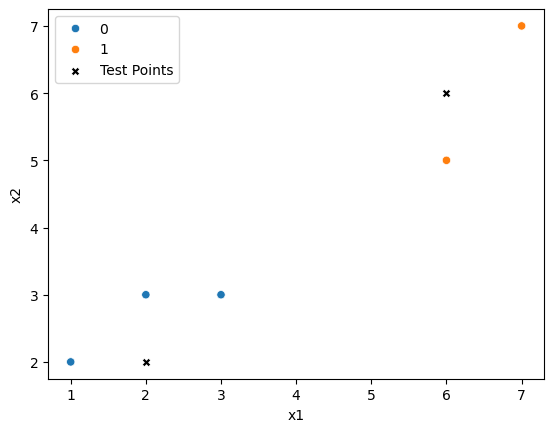

In [14]:
# Visualize
X_train_df = pd.DataFrame(X_train, columns=["x1", "x2"])
X_train_df["label"] = y_train

sns.scatterplot(
    data=X_train_df,
    x="x1",
    y="x2",
    hue="label"
)

X_test_df = pd.DataFrame(X_test, columns=["x1", "x2"])

sns.scatterplot(
    data=X_test_df,
    x="x1",
    y="x2",
    color="black",
    marker="X",
    label="Test Points"
)

In [15]:
X_train_df

,x1,x2,label
0,1,2,0
1,2,3,0
2,3,3,0
3,6,5,1
4,7,7,1
